<a href="https://colab.research.google.com/github/BipanaRoka/Sales_Analysis/blob/main/Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
sales=pd.read_csv("sales_data.csv")

In [32]:
sales.shape

(1000, 14)

In [33]:
sales.head()


,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [34]:
sales.columns

Index(['Product_ID', 'Sale_Date', 'Sales_Rep', 'Region', 'Sales_Amount',
       'Quantity_Sold', 'Product_Category', 'Unit_Cost', 'Unit_Price',
       'Customer_Type', 'Discount', 'Payment_Method', 'Sales_Channel',
       'Region_and_Sales_Rep'],
      dtype='object')

##### Sales_Rep represent the sales representative responsible for the transaction.Unit cost represent the cost per unit of the product sold.Unit price represent theselling price per unit of the product, calculated to be higher than the unit cost.

In [35]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   object 
 2   Sales_Rep             1000 non-null   object 
 3   Region                1000 non-null   object 
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   object 
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   object 
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   object 
 12  Sales_Channel         1000 non-null   object 
 13  Region_and_Sales_Rep  1000 non-null   object 
dtypes: float64(4), int64(2), object(8)
memory usage: 109.5+ KB


In [36]:
pd.isnull(sales).sum()

,0
Product_ID,0
Sale_Date,0
Sales_Rep,0
Region,0
Sales_Amount,0
Quantity_Sold,0
Product_Category,0
Unit_Cost,0
Unit_Price,0
Customer_Type,0


In [37]:
sales.describe()

,Product_ID,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1050.128000,5019.265230,25.355000,2475.304550,2728.440120,0.15239
std,29.573505,2846.790126,14.159006,1417.872546,1419.399839,0.08720
min,1001.000000,100.120000,1.000000,60.280000,167.120000,0.00000
25%,1024.000000,2550.297500,13.000000,1238.380000,1509.085000,0.08000
50%,1051.000000,5019.300000,25.000000,2467.235000,2696.400000,0.15000
75%,1075.000000,7507.445000,38.000000,3702.865000,3957.970000,0.23000
max,1100.000000,9989.040000,49.000000,4995.300000,5442.150000,0.30000


In [38]:
sales[['Quantity_Sold','Unit_Cost','Unit_Price']].describe()

,Quantity_Sold,Unit_Cost,Unit_Price
count,1000.000000,1000.000000,1000.000000
mean,25.355000,2475.304550,2728.440120
std,14.159006,1417.872546,1419.399839
min,1.000000,60.280000,167.120000
25%,13.000000,1238.380000,1509.085000
50%,25.000000,2467.235000,2696.400000
75%,38.000000,3702.865000,3957.970000
max,49.000000,4995.300000,5442.150000


##Exploratory Data Analysis

## Product



In [39]:
sales['Product_ID'].nunique()

100

In [40]:
top_10_products = (
    sales.groupby('Product_ID', as_index=False)['Quantity_Sold']
      .sum()
      .sort_values(by='Quantity_Sold', ascending=False)
      .head(10)
)

print(top_10_products)

    Product_ID  Quantity_Sold
89        1090            590
91        1092            548
61        1062            506
98        1099            502
57        1058            452
7         1008            407
32        1033            404
23        1024            398
60        1061            391
88        1089            390


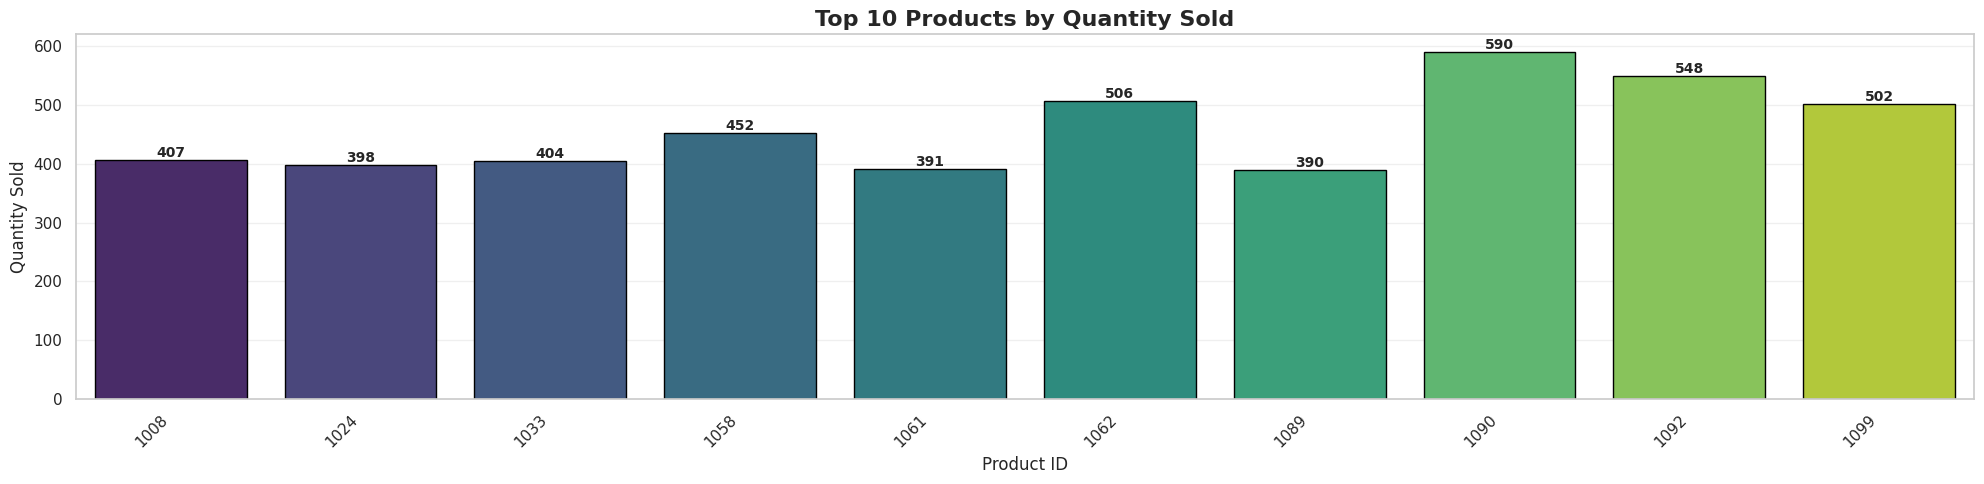

In [87]:
# Set figure size
plt.figure(figsize=(20, 5))

# Create barplot
ax = sns.barplot(data=top_10_products, x='Product_ID', y='Quantity_Sold',
                 palette='viridis', edgecolor='black')

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fontsize=10, fontweight='bold')

# Customize plot
plt.title('Top 10 Products by Quantity Sold', fontsize=16, fontweight='bold')
plt.xlabel('Product ID', fontsize=12)
plt.ylabel('Quantity Sold', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

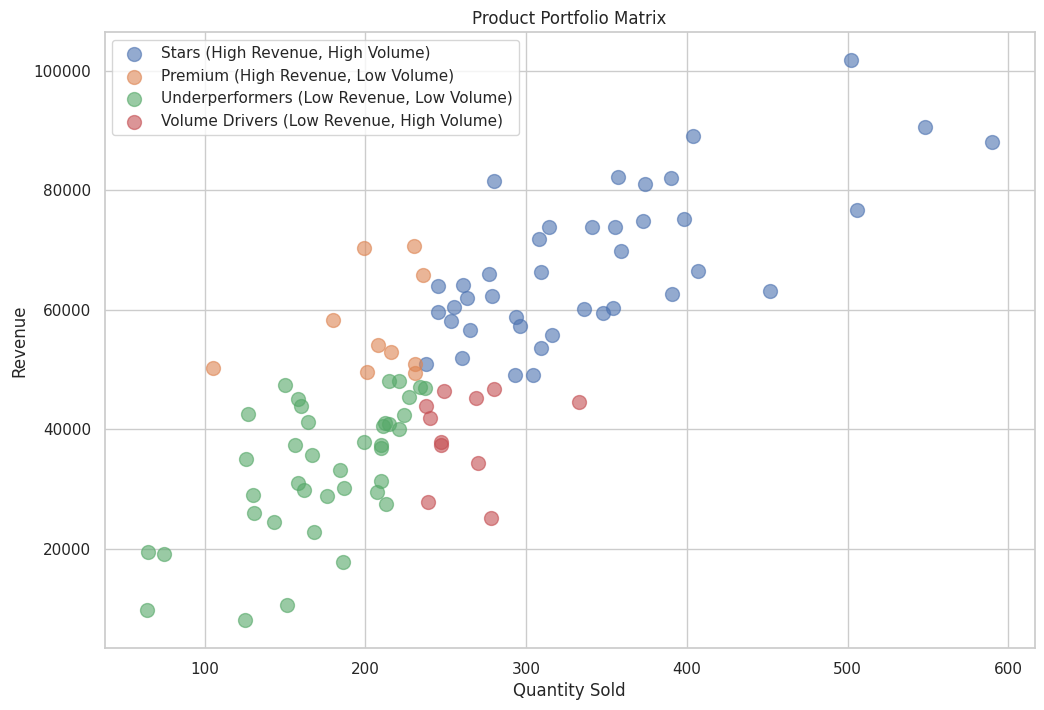

In [89]:
# Classify products by performance
product_analysis = sales.groupby('Product_ID').agg({
    'Sales_Amount': 'sum',
    'Quantity_Sold': 'sum',
    'Profit': 'sum'
})

# Categorize into high/low revenue and high/low volume
median_revenue = product_analysis['Sales_Amount'].median()
median_volume = product_analysis['Quantity_Sold'].median()

def classify_product(row):
    if row['Sales_Amount'] >= median_revenue and row['Quantity_Sold'] >= median_volume:
        return 'Stars (High Revenue, High Volume)'
    elif row['Sales_Amount'] >= median_revenue:
        return 'Premium (High Revenue, Low Volume)'
    elif row['Quantity_Sold'] >= median_volume:
        return 'Volume Drivers (Low Revenue, High Volume)'
    else:
        return 'Underperformers (Low Revenue, Low Volume)'

product_analysis['Segment'] = product_analysis.apply(classify_product, axis=1)

# Visualize
plt.figure(figsize=(12, 8))
for segment in product_analysis['Segment'].unique():
    data = product_analysis[product_analysis['Segment'] == segment]
    plt.scatter(data['Quantity_Sold'], data['Sales_Amount'],
                label=segment, s=100, alpha=0.6)
plt.xlabel('Quantity Sold')
plt.ylabel('Revenue')
plt.title('Product Portfolio Matrix')
plt.legend()

Category


   Category  Total_Revenue  Total_Quantity  Product_Count  Revenue_Per_Product Performance_Group
   Clothing     1313474.36            6922             93         14123.380215   High Performers
Electronics     1243499.64            6096             88         14130.677727 Medium Performers
       Food     1201773.54            5608             93         12922.296129    Low Performers
  Furniture     1260517.69            6729             91         13851.842747 Medium Performers


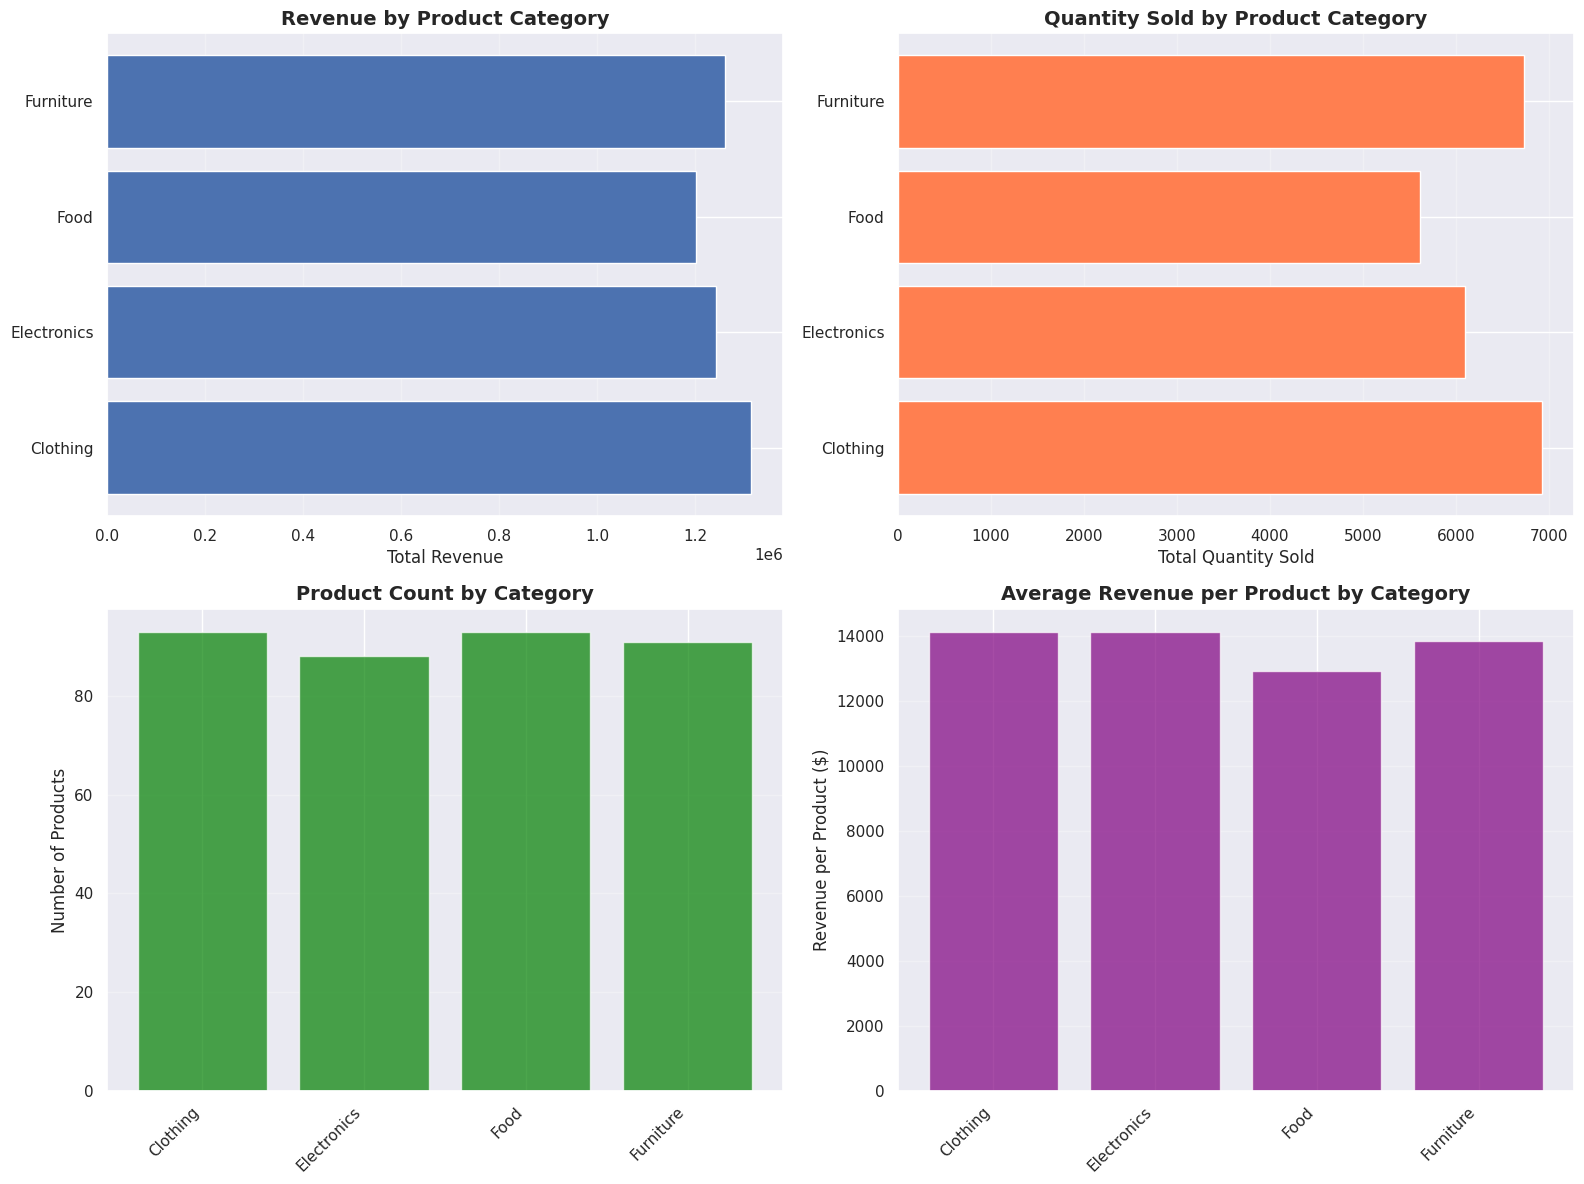

In [81]:
category_performance = sales.groupby('Product_Category').agg({
    'Sales_Amount': 'sum',
    'Quantity_Sold': 'sum',
    'Product_ID': 'nunique'
}).reset_index()

category_performance.columns = ['Category', 'Total_Revenue', 'Total_Quantity', 'Product_Count']

# Calculate revenue per product
category_performance['Revenue_Per_Product'] = (
    category_performance['Total_Revenue'] / category_performance['Product_Count']
)

# Categorize performance
category_performance['Performance_Group'] = pd.cut(
    category_performance['Total_Revenue'],
    bins=3,
    labels=['Low Performers', 'Medium Performers', 'High Performers']
)

print("\n" + category_performance.to_string(index=False))

# Visualize category performance
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Revenue by category
axes[0, 0].barh(category_performance['Category'], category_performance['Total_Revenue'])
axes[0, 0].set_xlabel('Total Revenue', fontsize=12)
axes[0, 0].set_title('Revenue by Product Category', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='x')

# 2. Quantity by category
axes[0, 1].barh(category_performance['Category'], category_performance['Total_Quantity'], color='coral')
axes[0, 1].set_xlabel('Total Quantity Sold', fontsize=12)
axes[0, 1].set_title('Quantity Sold by Product Category', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# 3. Product count by category
axes[1, 0].bar(range(len(category_performance)), category_performance['Product_Count'], color='green', alpha=0.7)
axes[1, 0].set_xticks(range(len(category_performance)))
axes[1, 0].set_xticklabels(category_performance['Category'], rotation=45, ha='right')
axes[1, 0].set_ylabel('Number of Products', fontsize=12)
axes[1, 0].set_title('Product Count by Category', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Revenue per product
axes[1, 1].bar(range(len(category_performance)), category_performance['Revenue_Per_Product'], color='purple', alpha=0.7)
axes[1, 1].set_xticks(range(len(category_performance)))
axes[1, 1].set_xticklabels(category_performance['Category'], rotation=45, ha='right')
axes[1, 1].set_ylabel('Revenue per Product ($)', fontsize=12)
axes[1, 1].set_title('Average Revenue per Product by Category', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


In [45]:
top3_per_category = sales.groupby('Product_Category', group_keys=False).apply(lambda x: x.nlargest(3, 'Quantity_Sold'))
print(top3_per_category[['Product_Category','Product_ID','Quantity_Sold']])

    Product_Category  Product_ID  Quantity_Sold
69          Clothing        1036             49
957         Clothing        1079             49
161         Clothing        1096             48
170      Electronics        1032             49
203      Electronics        1097             49
425      Electronics        1008             49
73              Food        1006             49
282             Food        1094             49
885             Food        1010             49
91         Furniture        1078             49
144        Furniture        1078             49
184        Furniture        1084             49


/tmp/ipython-input-657641172.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top3_per_category = sales.groupby('Product_Category', group_keys=False).apply(lambda x: x.nlargest(3, 'Quantity_Sold'))


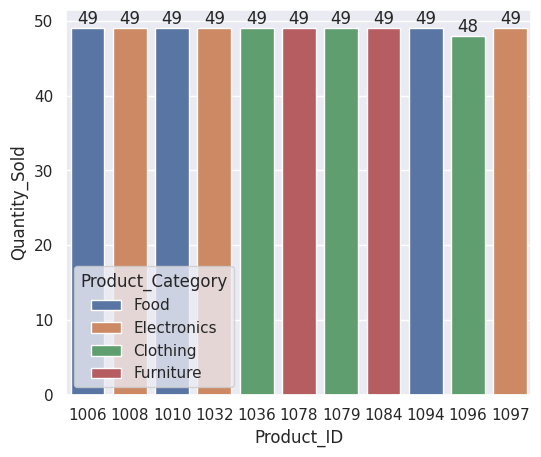

In [46]:
sns.set(rc={'figure.figsize':(6,5)})
ax=sns.barplot(data = top3_per_category, x = 'Product_ID',y= 'Quantity_Sold', hue='Product_Category')
for bars in ax.containers:
    ax.bar_label(bars)


##Region


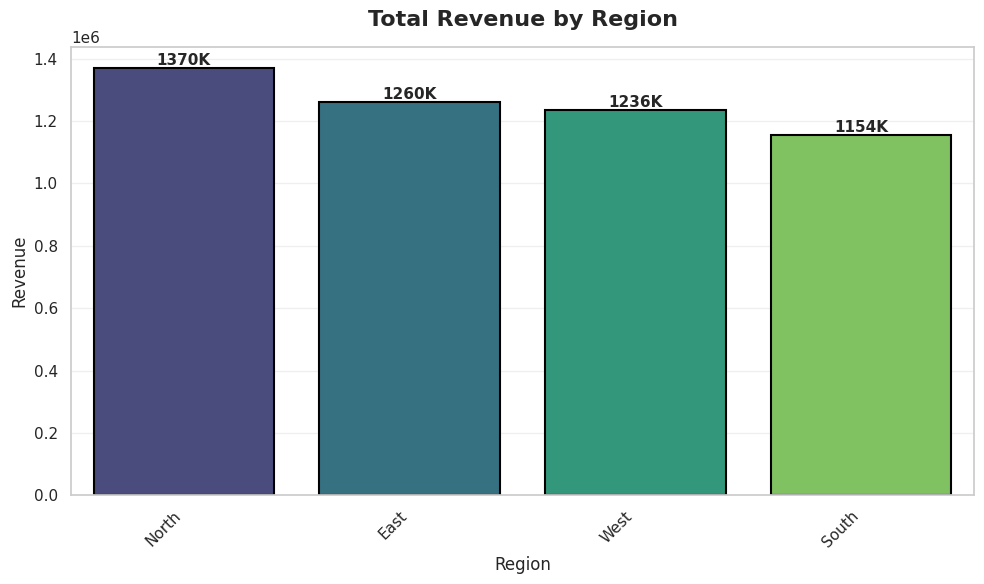


Regional Revenue Summary:
North: 1,369,612.51
East: 1,259,792.93
West: 1,235,608.93
South: 1,154,250.86


In [86]:
regional_data = sales.groupby('Region')['Sales_Amount'].sum().reset_index()
regional_data.columns = ['Region', 'Revenue']
regional_data = regional_data.sort_values('Revenue', ascending=False)
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
bars = sns.barplot(data=regional_data, x='Region', y='Revenue',
                   palette='viridis', edgecolor='black', linewidth=1.5)

# Add value labels on bars
for i, bar in enumerate(bars.patches):
    height = bar.get_height()
    bars.text(bar.get_x() + bar.get_width()/2., height,
            f'{height/1000:.0f}K', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

plt.title('Total Revenue by Region', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\nRegional Revenue Summary:")
print("="*40)
for _, row in regional_data.iterrows():
    print(f"{row['Region']}: {row['Revenue']:,.2f}")
print("="*40)

In [48]:
top2_per_Region = sales.groupby('Region', group_keys=False).apply(lambda x: x.nlargest(2, 'Quantity_Sold'))
print(top2_per_Region[['Region','Product_ID','Quantity_Sold']])

    Region  Product_ID  Quantity_Sold
91    East        1078             49
470   East        1030             49
69   North        1036             49
73   North        1006             49
144  South        1078             49
425  South        1008             49
170   West        1032             49
203   West        1097             49


/tmp/ipython-input-1657494725.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top2_per_Region = sales.groupby('Region', group_keys=False).apply(lambda x: x.nlargest(2, 'Quantity_Sold'))


###Sales Amount

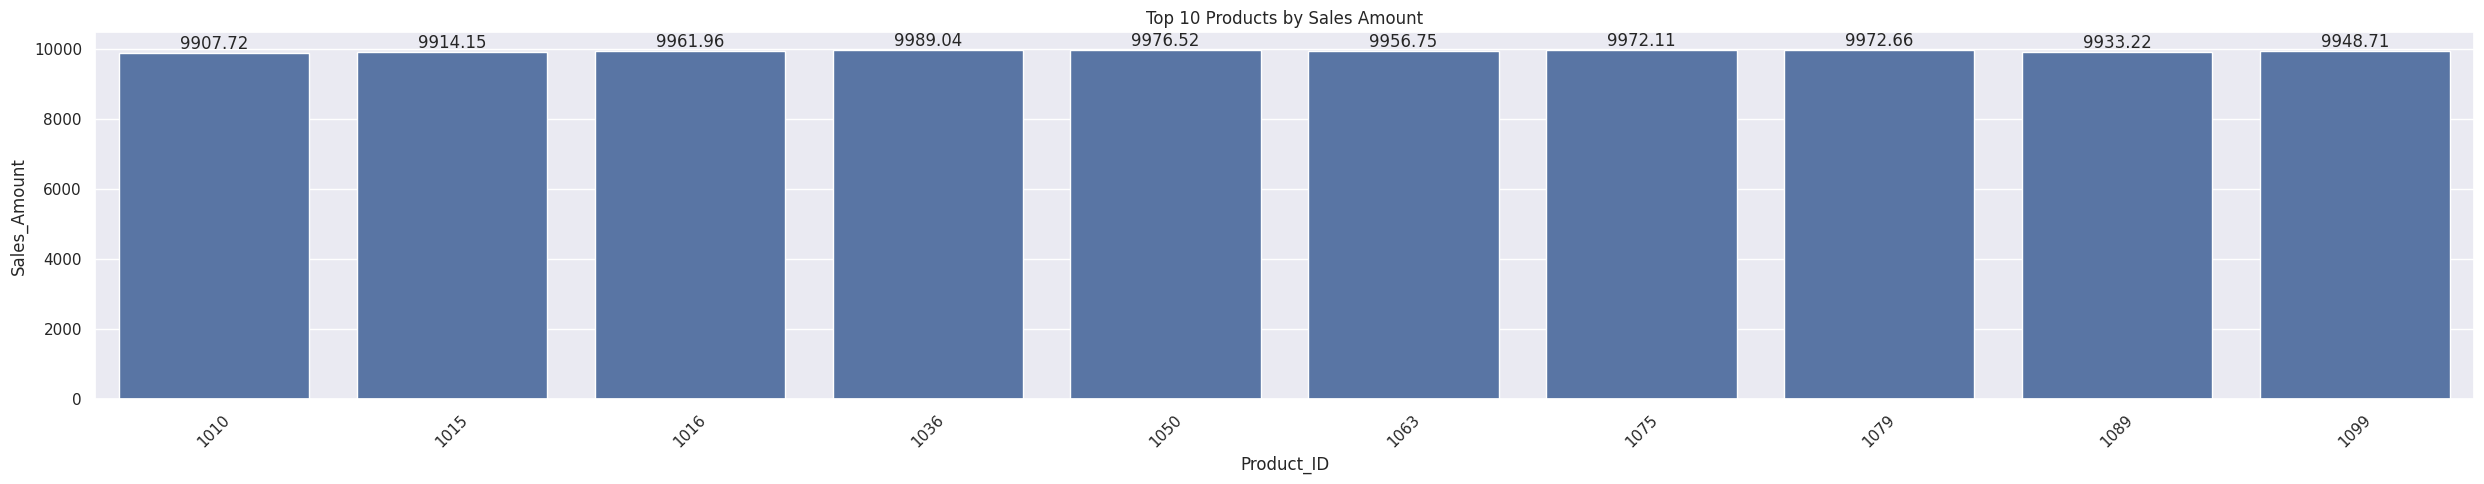

In [49]:
top_sales = sales.nlargest(10, 'Sales_Amount')
sns.set(rc={'figure.figsize': (25,5)})
ax = sns.barplot(
    data=top_sales,
    x='Product_ID',
    y='Sales_Amount'
)
for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=45)
plt.title('Top 10 Products by Sales Amount')
plt.tight_layout()
plt.show()


###Customer Type

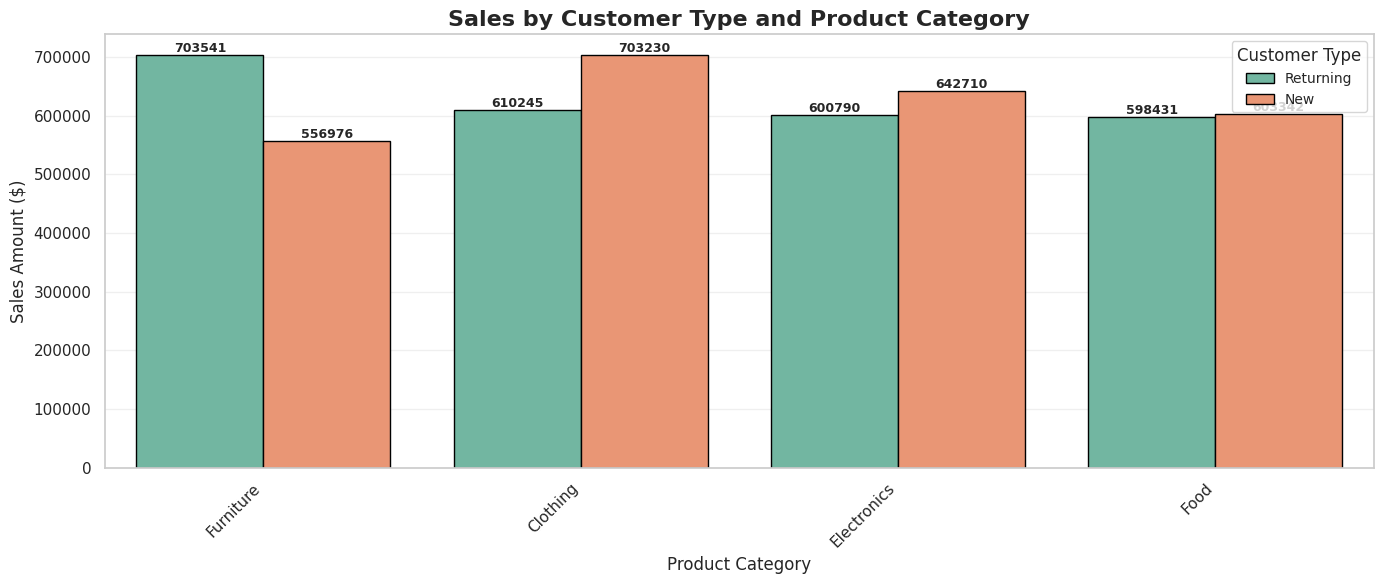


Sales by Customer Type and Category:
Customer_Type Product_Category  Sales_Amount
    Returning        Furniture     703541.41
          New         Clothing     703229.55
          New      Electronics     642710.00
    Returning         Clothing     610244.81
          New             Food     603342.47
    Returning      Electronics     600789.64
    Returning             Food     598431.07
          New        Furniture     556976.28


In [90]:
sales_by_customer = (
    sales.groupby(['Customer_Type', 'Product_Category'], as_index=False)['Sales_Amount']
    .sum()
    .sort_values(by='Sales_Amount', ascending=False)
)

# Create visualization
plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=sales_by_customer,
    x='Product_Category',
    y='Sales_Amount',
    hue='Customer_Type',
    palette='Set2',
    edgecolor='black'
)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fontsize=9, fontweight='bold', fmt='%.0f')

# Customize plot
plt.title('Sales by Customer Type and Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Sales Amount ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Customer Type', fontsize=10, loc='upper right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Print summary
print("\nSales by Customer Type and Category:")
print("="*70)
print(sales_by_customer.to_string(index=False))
print("="*70)

###Pricing and Cost Structure

####Total Profit (generated profit)


     Product_ID  Unit_Price  Unit_Cost  Discount      Profit
962        1090     5253.07    4766.53      0.01  20832.4464
529        1052      907.63     417.96      0.04  19041.3216
664        1040     2617.00    2189.54      0.01  18860.6300
555        1012      803.71     325.75      0.12  17931.1956
944        1086      526.14      83.86      0.11  17682.6116
560        1074     1848.69    1394.74      0.00  17250.1000
880        1051      666.64     287.99      0.00  16281.9500
86         1014     2527.00    2091.21      0.01  15599.7600
493        1061      498.46     146.27      0.06  15147.2728
397        1047     1727.15    1249.17      0.08  14611.7440
393        1067      533.58     210.63      0.04  14477.1264
546        1024     3045.94    2693.99      0.01  14467.0770
638        1100     2472.98    2116.09      0.01  14282.8886
764        1100     5402.28    4991.09      0.00  13980.4600
667        1050      586.18     112.35      0.28  13936.4820


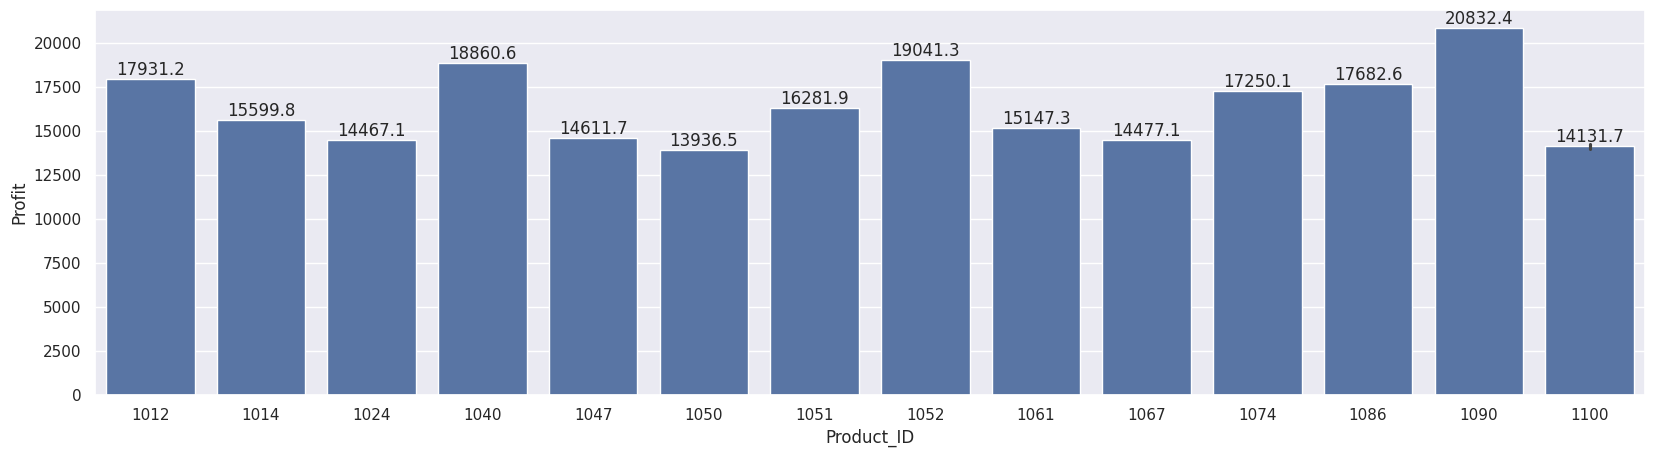

In [70]:
sales['Discounted_Price'] = sales['Unit_Price'] * (1 - sales['Discount'])
sales['Profit'] = (sales['Discounted_Price'] - sales['Unit_Cost']) * sales['Quantity_Sold']
top_15_profit = sales.nlargest(15, 'Profit', keep='first')
print(
    top_15_profit[['Product_ID', 'Unit_Price', 'Unit_Cost','Discount','Profit']]
)
sns.set(rc={'figure.figsize':(20,5)})
ax=sns.barplot(data=top_15_profit, x='Product_ID', y='Profit')
for bars in ax.containers:
    ax.bar_label(bars)

#####Unit Profit (per product)

     Product_ID  Unit_Price  Unit_Cost  Discount    Profit
340        1059      715.06     224.32      0.01  483.5894
177        1045      799.04     316.22      0.00  482.8200
560        1074     1848.69    1394.74      0.00  453.9500
529        1052      907.63     417.96      0.04  453.3648
171        1071     3185.81    2701.39      0.01  452.5619
122        1005      802.43     319.83      0.04  450.5028
458        1005     4818.95    4376.37      0.00  442.5800
962        1090     5253.07    4766.53      0.01  434.0093
136        1099     1955.56    1531.20      0.00  424.3600
700        1020      675.91     184.05      0.10  424.2690
936        1049     1004.08     558.70      0.03  415.2576
764        1100     5402.28    4991.09      0.00  411.1900
313        1089     4706.70    4248.50      0.01  411.1330
86         1014     2527.00    2091.21      0.01  410.5200
664        1040     2617.00    2189.54      0.01  401.2900


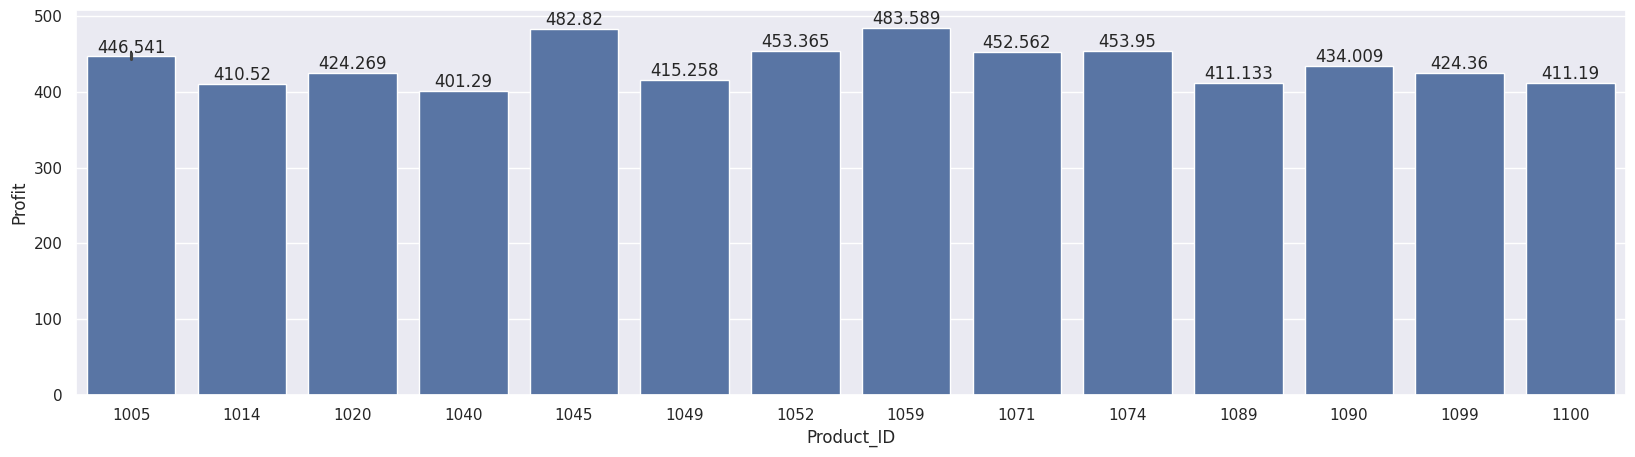

In [71]:
sales['Discounted_Price'] = sales['Unit_Price'] * (1 - sales['Discount'])
sales['Profit'] = (sales['Discounted_Price'] - sales['Unit_Cost'])
top_15_profit = sales.nlargest(15, 'Profit', keep='first')
print(
    top_15_profit[['Product_ID', 'Unit_Price', 'Unit_Cost','Discount','Profit']]
)
sns.set(rc={'figure.figsize':(20,5)})
ax=sns.barplot(data=top_15_profit, x='Product_ID', y='Profit')
for bars in ax.containers:
    ax.bar_label(bars)

####Sale Date


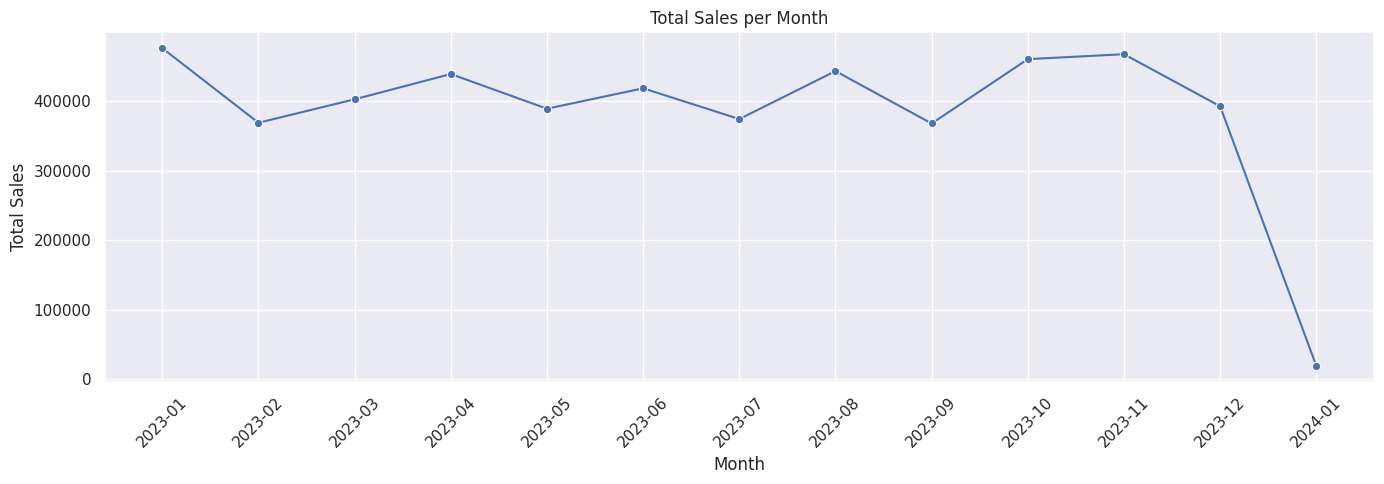

In [58]:
sales['Sale_Date'] = pd.to_datetime(sales['Sale_Date'])
sales['Year_Month'] = sales['Sale_Date'].dt.to_period('M')
monthly_sales = (
    sales
    .groupby('Year_Month', as_index=False)['Sales_Amount']
    .sum()
)

monthly_sales['Year_Month'] = monthly_sales['Year_Month'].astype(str)
sns.set(rc={'figure.figsize': (14, 5)})

sns.lineplot(
    data=monthly_sales,
    x='Year_Month',
    y='Sales_Amount',
    marker='o'
)

plt.title('Total Sales per Month')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



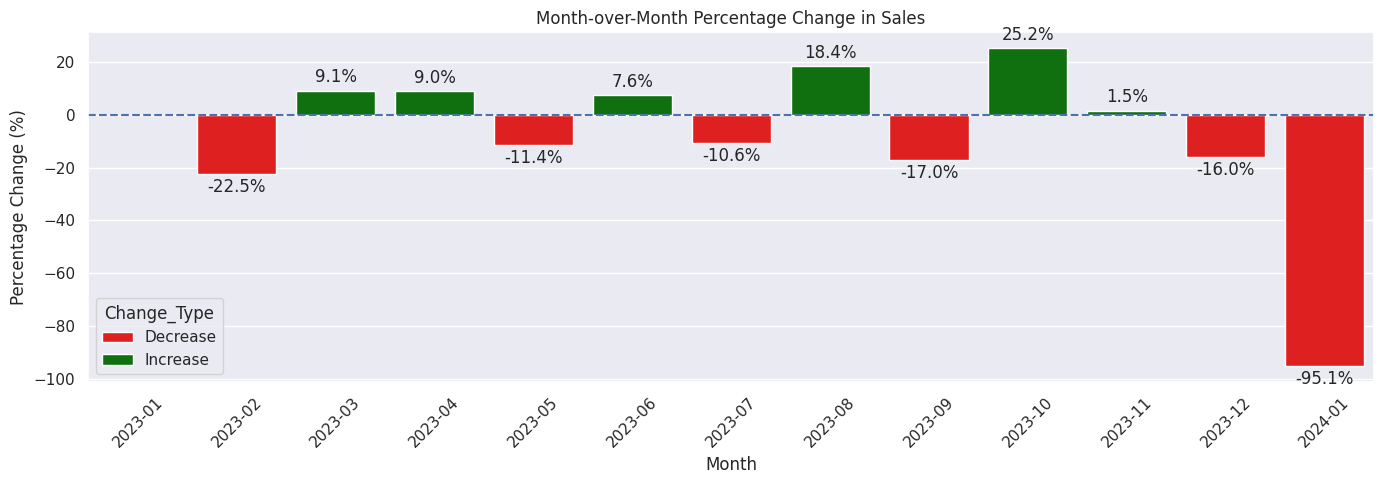

In [62]:

sales['Sale_Date'] = pd.to_datetime(sales['Sale_Date'])
sales['Year_Month'] = sales['Sale_Date'].dt.to_period('M')
monthly_sales = (
    sales
    .groupby('Year_Month', as_index=False)['Sales_Amount']
    .sum()
)

# Convert Period to string for plotting
monthly_sales['Year_Month'] = monthly_sales['Year_Month'].astype(str)

# Calculate Month-over-Month percentage change
monthly_sales['MoM_Percentage_Change'] = (
    monthly_sales['Sales_Amount'].pct_change() * 100
)

monthly_sales['Change_Type'] = monthly_sales['MoM_Percentage_Change'].apply(
    lambda x: 'Increase' if x >= 0 else 'Decrease'
)

sns.set(rc={'figure.figsize': (14, 5)})

ax = sns.barplot(
    data=monthly_sales,
    x='Year_Month',
    y='MoM_Percentage_Change',
    hue='Change_Type',
    palette={'Increase': 'green', 'Decrease': 'red'}
)


ax.axhline(0, linestyle='--')
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='edge',
        padding=3
    )

plt.title('Month-over-Month Percentage Change in Sales')
plt.xlabel('Month')
plt.ylabel('Percentage Change (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


####Payment Method and Sales Channel

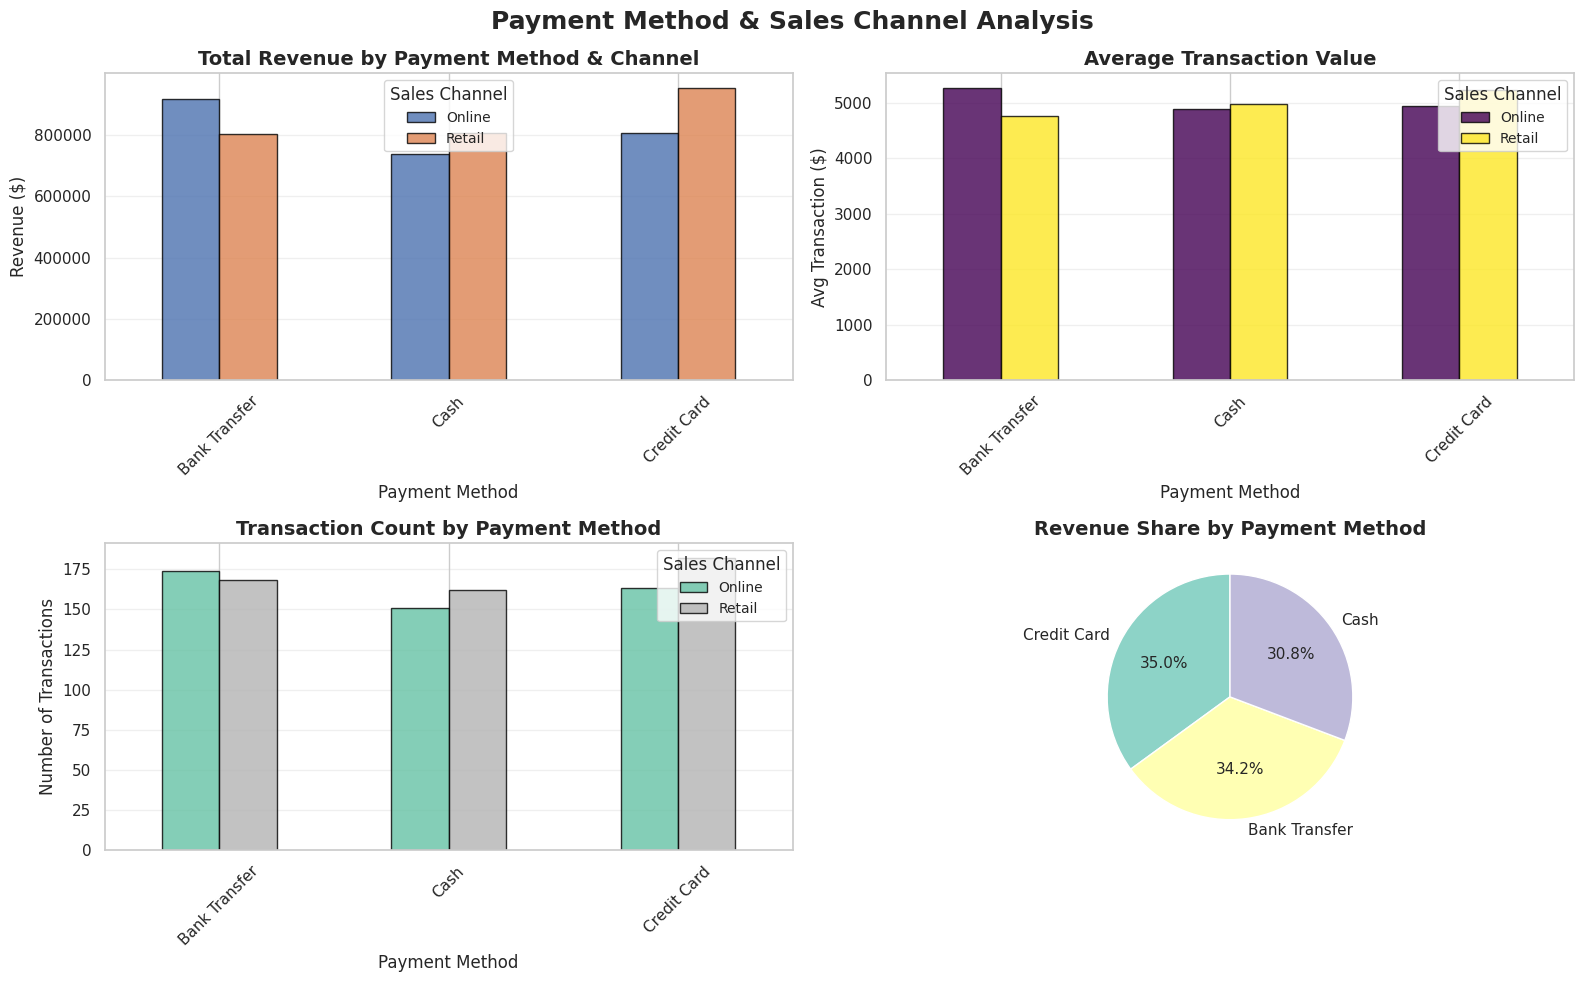


💳 PAYMENT METHOD PERFORMANCE SUMMARY

                Total_Revenue  Avg_Transaction  Transaction_Count  Revenue_Share_%
Payment_Method                                                                    
Credit Card        1757563.52          5094.39                345            35.02
Bank Transfer      1717363.17          5021.53                342            34.22
Cash               1544338.54          4933.99                313            30.77

📺 PREFERRED CHANNEL BY PAYMENT METHOD
Cash: Retail (51.8% of transactions)
Bank Transfer: Online (50.9% of transactions)
Credit Card: Retail (52.8% of transactions)


In [91]:

# Analyze payment method by revenue AND volume
payment_analysis = sales.groupby(['Payment_Method', 'Sales_Channel']).agg({
    'Sales_Amount': ['sum', 'mean'],
    'Product_ID': 'count'
}).reset_index()

payment_analysis.columns = ['Payment_Method', 'Sales_Channel', 'Total_Revenue',
                            'Avg_Transaction', 'Transaction_Count']

# Create 2x2 dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Payment Method & Sales Channel Analysis', fontsize=18, fontweight='bold')

# 1. Total Revenue by Payment Method and Channel
ax1 = axes[0, 0]
revenue_pivot = payment_analysis.pivot(index='Payment_Method',
                                       columns='Sales_Channel',
                                       values='Total_Revenue')
revenue_pivot.plot(kind='bar', ax=ax1, edgecolor='black', alpha=0.8)
ax1.set_title('Total Revenue by Payment Method & Channel', fontsize=14, fontweight='bold')
ax1.set_ylabel('Revenue ', fontsize=12)
ax1.set_xlabel('Payment Method', fontsize=12)
ax1.legend(title='Sales Channel', fontsize=10)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3, axis='y')

# 2. Average Transaction Value
ax2 = axes[0, 1]
avg_pivot = payment_analysis.pivot(index='Payment_Method',
                                   columns='Sales_Channel',
                                   values='Avg_Transaction')
avg_pivot.plot(kind='bar', ax=ax2, colormap='viridis', edgecolor='black', alpha=0.8)
ax2.set_title('Average Transaction Value', fontsize=14, fontweight='bold')
ax2.set_ylabel('Avg Transaction ($)', fontsize=12)
ax2.set_xlabel('Payment Method', fontsize=12)
ax2.legend(title='Sales Channel', fontsize=10)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

# 3. Transaction Count (your original insight)
ax3 = axes[1, 0]
count_pivot = payment_analysis.pivot(index='Payment_Method',
                                     columns='Sales_Channel',
                                     values='Transaction_Count')
count_pivot.plot(kind='bar', ax=ax3, colormap='Set2', edgecolor='black', alpha=0.8)
ax3.set_title('Transaction Count by Payment Method', fontsize=14, fontweight='bold')
ax3.set_ylabel('Number of Transactions', fontsize=12)
ax3.set_xlabel('Payment Method', fontsize=12)
ax3.legend(title='Sales Channel', fontsize=10)
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, alpha=0.3, axis='y')

# 4. Payment Method Market Share (%)
ax4 = axes[1, 1]
payment_share = sales.groupby('Payment_Method')['Sales_Amount'].sum().sort_values(ascending=False)
colors = plt.cm.Set3(range(len(payment_share)))
ax4.pie(payment_share, labels=payment_share.index, autopct='%1.1f%%',
        colors=colors, startangle=90, textprops={'fontsize': 11})
ax4.set_title('Revenue Share by Payment Method', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print detailed summary
print("\n" + "="*80)
print(" PAYMENT METHOD PERFORMANCE SUMMARY")
print("="*80)

summary = sales.groupby('Payment_Method').agg({
    'Sales_Amount': ['sum', 'mean'],
    'Product_ID': 'count'
}).round(2)

summary.columns = ['Total_Revenue', 'Avg_Transaction', 'Transaction_Count']
summary['Revenue_Share_%'] = (summary['Total_Revenue'] / summary['Total_Revenue'].sum() * 100).round(2)
summary = summary.sort_values('Total_Revenue', ascending=False)

print("\n" + summary.to_string())
print("="*80)

# Channel preference analysis
print("\n" + "="*80)
print("📺 PREFERRED CHANNEL BY PAYMENT METHOD")
print("="*80)

for payment in sales['Payment_Method'].unique():
    channel_dist = sales[sales['Payment_Method'] == payment]['Sales_Channel'].value_counts()
    top_channel = channel_dist.index[0]
    percentage = (channel_dist.iloc[0] / channel_dist.sum() * 100)
    print(f"{payment}: {top_channel} ({percentage:.1f}% of transactions)")
print("="*80)